In [45]:
import mytorch
import matplotlib.pyplot as plt
import mytorch.layer
import mytorch.activation
import mytorch.optimizer
import mytorch.loss
import pandas as pd
from mytorch.tensor import Tensor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
# from torch.utils.data import DataLoader, TensorDataset

In [46]:
import numpy as np
FILE_PATH = r".\diabetes.csv"

In [47]:
df = pd.read_csv(FILE_PATH, header=0)

# Rename Outcome to Diagnosis and convert to binary (already 0/1)
df = df.rename(columns={"Outcome": "Diagnosis"})

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [48]:
columns_to_fix_med = ['Glucose', 'BloodPressure']
columns_to_fix_mea = ['BMI','SkinThickness','Insulin']

for col in columns_to_fix_mea:
    zero_count = (df[col] == 0).sum()
    df[col] = df[col].replace(0, np.nan)
    
    mean_value = df[col].mean()
    df[col] = df[col].replace(np.nan, mean_value)
    
for col in columns_to_fix_med:
    zero_count = (df[col] == 0).sum()
    df[col] = df[col].replace(0, np.nan)
    
    median_value = df[col].median()
    df[col] = df[col].replace(np.nan, median_value)

In [49]:
X = df.drop(columns=["Diagnosis"]).values
y = df["Diagnosis"].values
y = y.reshape(-1, 1) 

scaler= StandardScaler()
X = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

scaler= StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train = mytorch.Tensor(X_train)
y_train = mytorch.Tensor(y_train)   

X_test_org = mytorch.Tensor(X_test)
y_test_org = mytorch.Tensor(y_test) 

X_test = mytorch.Tensor(X_val)
y_test = mytorch.Tensor(y_val)



In [50]:
          
# def init_weights(layer, method='xavier'):
#     """Initialize weights properly"""
#     if hasattr(layer, 'W') and hasattr(layer.W, 'data'):
#         fan_in, fan_out = layer.W.data.shape
        
#         if method == 'xavier':
#             limit = np.sqrt(6.0 / (fan_in + fan_out))
#             layer.W.data = np.random.uniform(-limit, limit, (fan_in, fan_out))
#         elif method == 'he':
#             std = np.sqrt(2.0 / fan_in)
#             layer.W.data = np.random.randn(fan_in, fan_out) * std
        
#         if hasattr(layer, 'b') and hasattr(layer.b, 'data'):
#             layer.b.data = np.zeros(layer.b.data.shape)
            
            
class MLP2(mytorch.Model):
    def __init__(self, input_size):
        super(MLP2, self).__init__()
        self.l1 = mytorch.layer.Linear(input_size, 64)
        self.l2 = mytorch.layer.Linear(64, 32)
        self.l3 = mytorch.layer.Linear(32, 16)
        self.l4 = mytorch.layer.Linear(16, 1)
        
        self.layers = [self.l1, self.l2, self.l3, self.l4]
        
        # for layer in self.layers:
        #     init_weights(layer, method='he')
        
        self.relu = mytorch.activation.relu
        self.sigmoid = mytorch.activation.sigmoid
    
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        x = self.relu(self.l3(x))
        x = self.sigmoid(self.l4(x))
        return x
        


In [51]:
y_train_binary = mytorch.Tensor(y_train.data.astype(float))
y_test_binary = mytorch.Tensor(y_test.data.astype(float))
input_size = X.shape[1]
model = MLP2(input_size)
optimizer = mytorch.optimizer.Adam(model.layers, lr=0.0001)
NUM_EPOCHS = 50

In [52]:
metrics_df = pd.DataFrame(columns=["Epoch", 
                                   "Train_Loss", "Train_Accuracy", 
                                   "Val_Loss", "Val_Accuracy"])


In [53]:
train_accuracy_list = []
test_accuracy_list = []

batch_size = 64
for epoch in range(NUM_EPOCHS):

    total = 0
    corrects = 0
    running_loss = 0.0

    for i in range(0, X_train.shape[0], batch_size):
        inputs = X_train[i:i+batch_size]
        labels = y_train[i:i+batch_size]
        
        optimizer.zero_grad()
        outputs = model.forward(inputs)
        
        loss = mytorch.loss.ce.BinaryCrossEntropy(outputs, labels) 
        # grad = (outputs.data - labels.data)
        loss = loss.sum()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.data.sum()
        total += labels.data.shape[0]
        
        pred = (outputs.data > 0.5).astype(float)
        corrects += (pred == labels.data).astype(int).sum().item()
        
        
    train_loss = running_loss / total
    train_accuracy = corrects / total
    train_accuracy_list.append(train_accuracy)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {train_loss:.4f}, Accuracy: {train_accuracy:.4f}")
    
    
    outputs_test = model.forward(X_test)
    val_loss_tensor = mytorch.loss.ce.BinaryCrossEntropy(outputs_test, y_test)
    val_loss = val_loss_tensor.data.sum() / y_test.data.shape[0]
    pred_test = (outputs_test.data > 0.5).astype(float)
    correct = (pred_test == y_test_binary.data).astype(int).sum().item()
    
    total = y_test_binary.data.shape[0]
    accuracy = correct / total
    test_accuracy_list.append(accuracy)
    
    metrics_df = pd.concat([metrics_df, 
                            pd.DataFrame.from_dict([{
                                "Epoch": epoch+1,
                                "Train_Loss": train_loss,
                                "Train_Accuracy": train_accuracy,
                                "Val_Loss": val_loss,
                                "Val_Accuracy": accuracy
                            }])], ignore_index=True)
    
    print(f"Test Accuracy: {accuracy:.4f}", end="\n\n")
    


initialize cache
initialize cache
initialize cache
initialize cache
Epoch 1/50, Loss: 0.6788, Accuracy: 0.5870
Test Accuracy: 0.6623

Epoch 2/50, Loss: 0.6731, Accuracy: 0.6065
Test Accuracy: 0.6818

Epoch 3/50, Loss: 0.6677, Accuracy: 0.6152
Test Accuracy: 0.6753

Epoch 4/50, Loss: 0.6623, Accuracy: 0.6370
Test Accuracy: 0.6753

Epoch 5/50, Loss: 0.6569, Accuracy: 0.6457
Test Accuracy: 0.6753

Epoch 6/50, Loss: 0.6515, Accuracy: 0.6587
Test Accuracy: 0.6753

Epoch 7/50, Loss: 0.6459, Accuracy: 0.6565
Test Accuracy: 0.6883

Epoch 8/50, Loss: 0.6404, Accuracy: 0.6630
Test Accuracy: 0.6883

Epoch 9/50, Loss: 0.6347, Accuracy: 0.6696
Test Accuracy: 0.6883

Epoch 10/50, Loss: 0.6290, Accuracy: 0.6674
Test Accuracy: 0.6948

Epoch 11/50, Loss: 0.6233, Accuracy: 0.6674
Test Accuracy: 0.6948

Epoch 12/50, Loss: 0.6178, Accuracy: 0.6717
Test Accuracy: 0.7013

Epoch 13/50, Loss: 0.6123, Accuracy: 0.6804
Test Accuracy: 0.7013

Epoch 14/50, Loss: 0.6070, Accuracy: 0.6826
Test Accuracy: 0.7013

Epo

C:\Users\asus\AppData\Local\Temp\ipykernel_27412\949096221.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df,


Epoch 22/50, Loss: 0.5687, Accuracy: 0.6935
Test Accuracy: 0.7208

Epoch 23/50, Loss: 0.5645, Accuracy: 0.6957
Test Accuracy: 0.7143

Epoch 24/50, Loss: 0.5604, Accuracy: 0.6978
Test Accuracy: 0.7208

Epoch 25/50, Loss: 0.5564, Accuracy: 0.7065
Test Accuracy: 0.7208

Epoch 26/50, Loss: 0.5525, Accuracy: 0.7152
Test Accuracy: 0.7208

Epoch 27/50, Loss: 0.5487, Accuracy: 0.7196
Test Accuracy: 0.7208

Epoch 28/50, Loss: 0.5450, Accuracy: 0.7174
Test Accuracy: 0.7208

Epoch 29/50, Loss: 0.5414, Accuracy: 0.7196
Test Accuracy: 0.7208

Epoch 30/50, Loss: 0.5379, Accuracy: 0.7239
Test Accuracy: 0.7273

Epoch 31/50, Loss: 0.5344, Accuracy: 0.7261
Test Accuracy: 0.7338

Epoch 32/50, Loss: 0.5312, Accuracy: 0.7261
Test Accuracy: 0.7403

Epoch 33/50, Loss: 0.5279, Accuracy: 0.7283
Test Accuracy: 0.7532

Epoch 34/50, Loss: 0.5248, Accuracy: 0.7283
Test Accuracy: 0.7532

Epoch 35/50, Loss: 0.5219, Accuracy: 0.7261
Test Accuracy: 0.7532

Epoch 36/50, Loss: 0.5190, Accuracy: 0.7283
Test Accuracy: 0.7

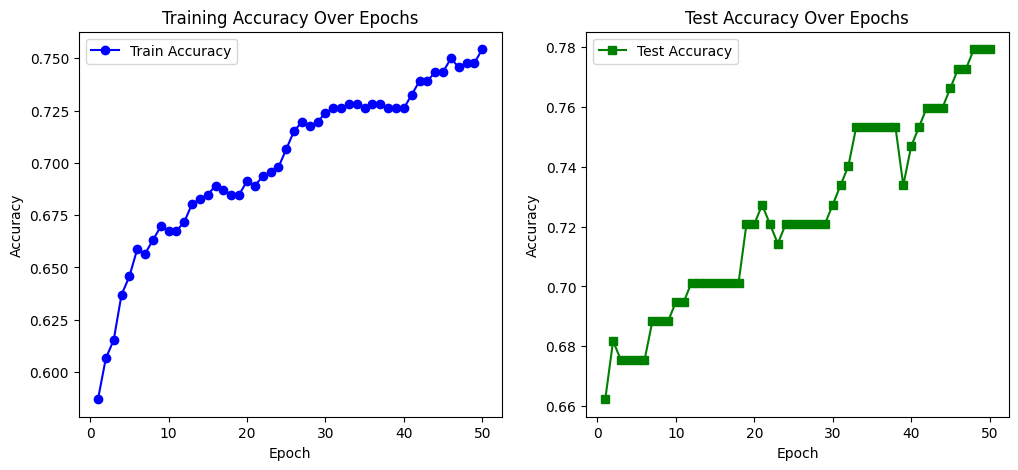

In [54]:
# don't change this cell
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_EPOCHS+1), train_accuracy_list, marker='o', linestyle='-', color='b', label="Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, NUM_EPOCHS+1), test_accuracy_list, marker='s', linestyle='-', color='g', label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy Over Epochs")
plt.legend()

plt.show()

In [55]:
print(metrics_df)

   Epoch  Train_Loss  Train_Accuracy  Val_Loss  Val_Accuracy
0      1    0.678788        0.586957  0.668033      0.662338
1      2    0.673119        0.606522  0.662770      0.681818
2      3    0.667692        0.615217  0.657624      0.675325
3      4    0.662314        0.636957  0.652575      0.675325
4      5    0.656906        0.645652  0.647464      0.675325
5      6    0.651454        0.658696  0.642191      0.675325
6      7    0.645923        0.656522  0.636888      0.688312
7      8    0.640355        0.663043  0.631585      0.688312
8      9    0.634658        0.669565  0.626289      0.688312
9     10    0.628963        0.667391  0.621007      0.694805
10    11    0.623345        0.667391  0.615721      0.694805
11    12    0.617820        0.671739  0.610420      0.701299
12    13    0.612338        0.680435  0.605111      0.701299
13    14    0.606964        0.682609  0.599892      0.701299
14    15    0.601686        0.684783  0.594790      0.701299
15    16    0.596592    

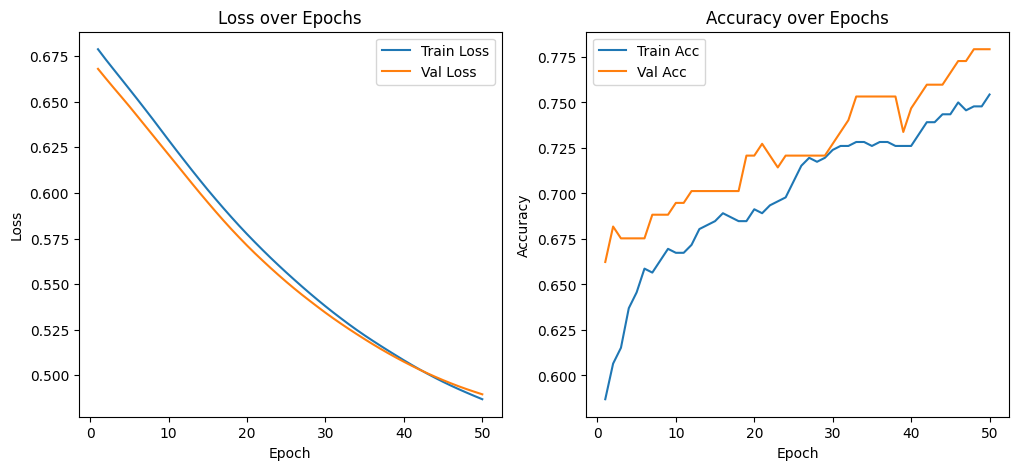

In [56]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(metrics_df['Epoch'], metrics_df['Train_Loss'], label='Train Loss')
plt.plot(metrics_df['Epoch'], metrics_df['Val_Loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(metrics_df['Epoch'], metrics_df['Train_Accuracy'], label='Train Acc')
plt.plot(metrics_df['Epoch'], metrics_df['Val_Accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()
